# Лабораторная работа №1: Apache Hadoop + Apache Spark
**Вариант 3: Складской учет**  
Датасет: OnlineRetail

# Цель
Загрузить данные в HDFS, выполнить обработку и анализ в PySpark, построить визуализацию и сохранить результаты в HDFS.

## Подготовка окружения
Работа выполняется в VM. Hadoop (HDFS+YARN) запущен, данные загружены в HDFS.
Дальнейшая обработка выполняется в JupyterLab с использованием PySpark.

In [1]:
import sys
!{sys.executable} -m pip install -q seaborn

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
spark = (
    SparkSession.builder
    .appName("lab_01_variant3_warehouse_online_retail")
    .config("spark.hadoop.fs.defaultFS", "hdfs://localhost:9000")
    .config("spark.sql.shuffle.partitions", "50")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

26/03/02 03:22:07 WARN Utils: Your hostname, devopsvm resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
26/03/02 03:22:07 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/02 03:22:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.3


In [4]:
hdfs_path = "hdfs://localhost:9000/user/hadoop/lab_01_var3/raw/OnlineRetail.csv"

df_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(hdfs_path)
)

df_raw.printSchema()
df_raw.show(5, truncate=False)
print("Rows:", df_raw.count())

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)

+---------+---------+-----------------------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate   |UnitPrice|CustomerID|Country       |
+---------+---------+-----------------------------------+--------+--------------+---------+----------+--------------+
|536365   |85123A   |WHITE HANGING HEART T-LIGHT HOLDER |6       |12/1/2010 8:26|2.55     |17850     |United Kingdom|
|536365   |71053    |WHITE METAL LANTERN                |6       |12/1/2010 8:26|3.39     |17850     |United Kingdom|
|536365   |84406B   |CREAM CUPID HEARTS COAT HANGER     |8       |12/1/2

# Предобработка

1. Преобразуем `InvoiceDate` в timestamp.
2. Удаляем строки без даты/кода товара и некорректные значения (`UnitPrice <= 0`, `Quantity = 0`).
3. Заполняем пропуски в `Description`.
4. Добавляем метрику `Revenue = Quantity * UnitPrice`.
5. Выделяем продажи: `Quantity > 0` (возвраты: `Quantity < 0`).

In [5]:
df = df_raw

df = df.withColumn("InvoiceTS", F.to_timestamp("InvoiceDate", "M/d/yyyy H:mm"))

df = (
    df.filter(F.col("InvoiceTS").isNotNull())
      .filter(F.col("StockCode").isNotNull())
      .filter(F.col("UnitPrice").isNotNull())
      .filter(F.col("Quantity").isNotNull())
      .filter(F.col("UnitPrice") > 0)
      .filter(F.col("Quantity") != 0)
)

df = df.withColumn("Description", F.coalesce(F.col("Description"), F.lit("Unknown")))

df = df.withColumn("Revenue", (F.col("Quantity") * F.col("UnitPrice")).cast("double"))

df = df.withColumn(
    "MovementType",
    F.when(F.col("Quantity") > 0, F.lit("SALE")).otherwise(F.lit("RETURN"))
)

print("Rows after cleaning:", df.count())
df.select("InvoiceNo","StockCode","Description","Quantity","InvoiceTS","UnitPrice","Revenue","MovementType","Country").show(5, truncate=False)

Rows after cleaning: 539392
+---------+---------+-----------------------------------+--------+-------------------+---------+------------------+------------+--------------+
|InvoiceNo|StockCode|Description                        |Quantity|InvoiceTS          |UnitPrice|Revenue           |MovementType|Country       |
+---------+---------+-----------------------------------+--------+-------------------+---------+------------------+------------+--------------+
|536365   |85123A   |WHITE HANGING HEART T-LIGHT HOLDER |6       |2010-12-01 08:26:00|2.55     |15.299999999999999|SALE        |United Kingdom|
|536365   |71053    |WHITE METAL LANTERN                |6       |2010-12-01 08:26:00|3.39     |20.34             |SALE        |United Kingdom|
|536365   |84406B   |CREAM CUPID HEARTS COAT HANGER     |8       |2010-12-01 08:26:00|2.75     |22.0              |SALE        |United Kingdom|
|536365   |84029G   |KNITTED UNION FLAG HOT WATER BOTTLE|6       |2010-12-01 08:26:00|3.39     |20.34       

In [6]:
before = df.count()
df = df.dropDuplicates()
after = df.count()
print("Rows before dropDuplicates:", before)
print("Rows after dropDuplicates:", after)

Rows before dropDuplicates: 539392
Rows after dropDuplicates: 534129


## Задание 1. Неликвидные товары (нет продаж > 30 дней)
Неликвид: нет продаж более 30 дней.
возвраты не учитываются как продажи (Quantity < 0).

In [7]:
sales = df.filter(F.col("MovementType") == "SALE")

max_ts = sales.agg(F.max("InvoiceTS").alias("max_ts")).collect()[0]["max_ts"]
print("Max sale timestamp:", max_ts)

last_sale = (
    sales.groupBy("StockCode")
         .agg(
             F.max("InvoiceTS").alias("last_sale_ts"),
             F.first("Description", ignorenulls=True).alias("Description")
         )
)

last_sale = last_sale.withColumn(
    "days_since_last_sale",
    F.datediff(F.lit(max_ts).cast("date"), F.col("last_sale_ts").cast("date"))
)

dead_stock_30 = (
    last_sale.filter(F.col("days_since_last_sale") > 30)
             .orderBy(F.col("days_since_last_sale").desc())
)

print("Dead stock items (>30 days):", dead_stock_30.count())
dead_stock_30.show(20, truncate=False)

Max sale timestamp: 2011-12-09 12:50:00


Dead stock items (>30 days): 984


+---------+-------------------+-----------------------------------+--------------------+
|StockCode|last_sale_ts       |Description                        |days_since_last_sale|
+---------+-------------------+-----------------------------------+--------------------+
|82615    |2010-12-01 16:11:00|PINK MARSHMALLOW SCARF KNITTING KIT|373                 |
|84854    |2010-12-01 09:41:00|GIRLY PINK TOOL SET                |373                 |
|16161M   |2010-12-02 18:15:00|WRAP  PINK FLOCK                   |372                 |
|21268    |2010-12-02 15:46:00|VINTAGE BLUE TINSEL REEL           |372                 |
|22275    |2010-12-02 16:51:00|WEEKEND BAG VINTAGE ROSE PAISLEY   |372                 |
|35271S   |2010-12-02 13:49:00|GOLD PRINT PAPER BAG               |372                 |
|72803b   |2010-12-03 11:28:00|OCEAN SCENT CANDLE JEWELLED DRAWER |371                 |
|84614A   |2010-12-03 15:45:00|PINK BAROQUE FLOCK CANDLE HOLDER   |371                 |
|85036b   |2010-12-03

## Задание 2. Spark SQL: критически низкий запас и коэффициент оборачиваемости

Так как в датасете нет явных складских остатков, формируем приближенную модель:
- дневные продажи по товару
- оценка среднего дневного спроса
- точка заказа (reorder point) = avg_daily_sales * lead_time_days
- текущий остаток (stock_on_hand) моделируем как initial_stock - cumulative_sales

In [8]:
spark.conf.set("spark.sql.shuffle.partitions", "12")
spark.conf.set("spark.default.parallelism", "12")

In [9]:
df = df.cache()
_ = df.count() 

In [10]:
lead_time_days = 7 # время поставки
safety_days = 3 # запас в днях
initial_stock_days = 30 # "начальный запас" в днях спроса

sales = df.filter(F.col("MovementType") == "SALE")

daily_sales = (
    sales
    .withColumn("SaleDate", F.to_date("InvoiceTS"))
    .groupBy("StockCode", "SaleDate")
    .agg(
        F.sum("Quantity").alias("qty_sold_day"),
        F.sum("Revenue").alias("rev_day")
    )
)

daily_sales.createOrReplaceTempView("daily_sales")
daily_sales.show(5, truncate=False)

+---------+----------+------------+------------------+
|StockCode|SaleDate  |qty_sold_day|rev_day           |
+---------+----------+------------+------------------+
|84991    |2010-12-01|78          |45.09             |
|22469    |2010-12-01|111         |207.64            |
|22195    |2010-12-01|34          |64.64999999999999 |
|21108    |2010-12-01|40          |157.21999999999997|
|21791    |2010-12-01|43          |57.53             |
+---------+----------+------------+------------------+
only showing top 5 rows



### 2.2 Оценка спроса и точки заказа (reorder point)

Оцениваем средний дневной спрос по каждому товару на основе таблицы `daily_sales`.
Точка заказа (в штуках) моделируется как:

**reorder_point_qty = avg_daily_sales * lead_time_days**

Cтраховой запас:
**safety_stock_qty = avg_daily_sales * safety_days**

In [11]:
spark.sql("SELECT COUNT(*) AS rows FROM daily_sales").show()

demand_sql = f"""
WITH demand AS (
  SELECT
    StockCode,
    AVG(qty_sold_day) AS avg_daily_sales,
    SUM(qty_sold_day) AS total_sold_qty,
    COUNT(*) AS active_days
  FROM daily_sales
  GROUP BY StockCode
)
SELECT
  StockCode,
  avg_daily_sales,
  total_sold_qty,
  active_days,
  (avg_daily_sales * {lead_time_days}) AS reorder_point_qty,
  (avg_daily_sales * {safety_days}) AS safety_stock_qty
FROM demand
ORDER BY avg_daily_sales DESC
"""

demand_df = spark.sql(demand_sql)
demand_df.show(15, truncate=False)

+------+
|  rows|
+------+
|276148|
+------+



+---------+------------------+--------------+-----------+------------------+------------------+
|StockCode|avg_daily_sales   |total_sold_qty|active_days|reorder_point_qty |safety_stock_qty  |
+---------+------------------+--------------+-----------+------------------+------------------+
|23843    |80995.0           |80995         |1          |566965.0          |242985.0          |
|47556B   |1300.0            |2600          |2          |9100.0            |3900.0            |
|23166    |624.264           |78033         |125        |4369.848          |1872.792          |
|16014    |272.0             |13328         |49         |1904.0            |816.0             |
|84077    |233.8340425531915 |54951         |235        |1636.8382978723405|701.5021276595745 |
|18007    |226.30769230769232|5884          |26         |1584.1538461538462|678.9230769230769 |
|23084    |226.02205882352942|30739         |136        |1582.1544117647059|678.0661764705883 |
|16033    |210.0             |840       

In [12]:
stock_sql = f"""
WITH demand AS (
  SELECT
    StockCode,
    AVG(qty_sold_day) AS avg_daily_sales,
    SUM(qty_sold_day) AS total_sold_qty,
    COUNT(*) AS active_days
  FROM daily_sales
  GROUP BY StockCode
),
model AS (
  SELECT
    StockCode,
    avg_daily_sales,
    total_sold_qty,
    active_days,
    (avg_daily_sales * {lead_time_days}) AS reorder_point_qty,
    (avg_daily_sales * {initial_stock_days}) AS initial_stock_qty,
    (avg_daily_sales * {initial_stock_days} - total_sold_qty) AS stock_on_hand_qty,
    (total_sold_qty / NULLIF((avg_daily_sales * {initial_stock_days})/2, 0)) AS turnover_qty
  FROM demand
  WHERE active_days >= 5   -- фильтр против разовых выбросов
)
SELECT *
FROM model
WHERE stock_on_hand_qty < reorder_point_qty
ORDER BY stock_on_hand_qty ASC
"""

low_stock_df = spark.sql(stock_sql)
print("Low stock items:", low_stock_df.count())
low_stock_df.show(20, truncate=False)

Low stock items: 2645


+---------+------------------+--------------+-----------+------------------+------------------+-------------------+------------------+
|StockCode|avg_daily_sales   |total_sold_qty|active_days|reorder_point_qty |initial_stock_qty |stock_on_hand_qty  |turnover_qty      |
+---------+------------------+--------------+-----------+------------------+------------------+-------------------+------------------+
|23166    |624.264           |78033         |125        |4369.848          |18727.920000000002|-59305.08          |8.333333333333332 |
|22197    |193.53061224489795|56898         |294        |1354.7142857142858|5805.918367346939 |-51092.08163265306 |19.6              |
|84077    |233.8340425531915 |54951         |235        |1636.8382978723405|7015.021276595745 |-47935.97872340425 |15.666666666666666|
|85099B   |161.23666666666668|48371         |300        |1128.6566666666668|4837.1            |-43533.9           |20.0              |
|85123A   |123.41311475409836|37641         |305       

## Задание 3. Визуализация: heatmap товарных остатков по категориям

Требуется построить тепловую карту остатков по категориям товаров.

Особенности OnlineRetail:
- в данных нет явных складских остатков, поэтому `stock_on_hand_qty` рассчитывается модельно на основе спроса
- в данных нет товарных категорий, поэтому категории формируем через **ABC-анализ** по выручке:
  - A: товары, дающие ~80% выручки
  - B: следующие ~15%
  - C: остальные товары

Для heatmap используем **диапазоны** остатков:
`<0 (deficit)`, `0-49`, `50-199`, `200-999`, `1000+`.

В ячейках heatmap отображается **количество товаров** в соответствующей категории ABC и диапазоне остатка.

In [13]:
# Выручка по товару (только продажи)
sales = df.filter(F.col("MovementType") == "SALE")

rev_by_item = (
    sales.groupBy("StockCode")
         .agg(F.sum("Revenue").alias("revenue"))
)

w = Window.orderBy(F.col("revenue").desc())

rev_abc = (
    rev_by_item
    .withColumn("total_revenue", F.sum("revenue").over(Window.rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing)))
    .withColumn("revenue_share", F.col("revenue") / F.col("total_revenue"))
    .withColumn("cum_share", F.sum("revenue_share").over(w))
    .withColumn(
        "ABC",
        F.when(F.col("cum_share") <= 0.80, F.lit("A"))
         .when(F.col("cum_share") <= 0.95, F.lit("B"))
         .otherwise(F.lit("C"))
    )
    .select("StockCode", "ABC")
)

rev_abc.groupBy("ABC").count().orderBy("ABC").show()

26/03/02 03:22:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:22:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:22:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:22:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:22:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:22:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 0

+---+-----+
|ABC|count|
+---+-----+
|  A|  802|
|  B|  983|
|  C| 2137|
+---+-----+



In [14]:
model_all_sql = f"""
WITH demand AS (
  SELECT
    StockCode,
    AVG(qty_sold_day) AS avg_daily_sales,
    SUM(qty_sold_day) AS total_sold_qty,
    COUNT(*) AS active_days
  FROM daily_sales
  GROUP BY StockCode
),
model AS (
  SELECT
    StockCode,
    avg_daily_sales,
    total_sold_qty,
    active_days,
    (avg_daily_sales * {lead_time_days}) AS reorder_point_qty,
    (avg_daily_sales * {initial_stock_days}) AS initial_stock_qty,
    (avg_daily_sales * {initial_stock_days} - total_sold_qty) AS stock_on_hand_qty
  FROM demand
  WHERE active_days >= 5
)
SELECT * FROM model
"""
model_df = spark.sql(model_all_sql)

# join с ABC категориями
model_cat = model_df.join(rev_abc, on="StockCode", how="left").fillna({"ABC": "C"})

# бины остатков
model_cat = model_cat.withColumn(
    "stock_bin",
    F.when(F.col("stock_on_hand_qty") < 0, F.lit("<0 (deficit)"))
     .when(F.col("stock_on_hand_qty") < 50, F.lit("0-49"))
     .when(F.col("stock_on_hand_qty") < 200, F.lit("50-199"))
     .when(F.col("stock_on_hand_qty") < 1000, F.lit("200-999"))
     .otherwise(F.lit("1000+"))
)

# сводная таблица: сколько товаров в каждом бине в каждой категории
heat_src = (
    model_cat.groupBy("ABC", "stock_bin")
             .agg(F.count("*").alias("items_cnt"))
)

heat_src.show(20, truncate=False)

26/03/02 03:22:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:22:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:22:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:22:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:22:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:22:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 0

+---+------------+---------+
|ABC|stock_bin   |items_cnt|
+---+------------+---------+
|A  |50-199      |4        |
|C  |1000+       |3        |
|C  |<0 (deficit)|685      |
|C  |0-49        |578      |
|B  |<0 (deficit)|928      |
|C  |50-199      |301      |
|A  |1000+       |1        |
|C  |200-999     |118      |
|B  |0-49        |29       |
|A  |0-49        |4        |
|B  |1000+       |1        |
|A  |<0 (deficit)|788      |
|B  |50-199      |13       |
|B  |200-999     |11       |
|A  |200-999     |1        |
+---+------------+---------+



26/03/02 03:22:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:22:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:22:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:22:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:22:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:22:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 0

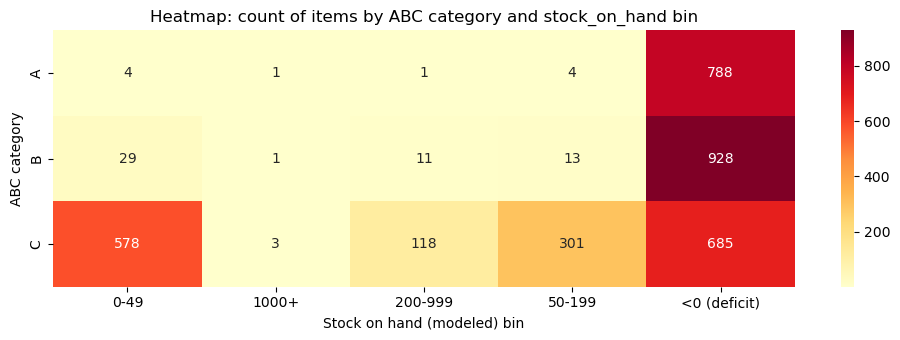

In [15]:
pdf = heat_src.toPandas()

pivot = pdf.pivot(index="ABC", columns="stock_bin", values="items_cnt").fillna(0)

plt.figure(figsize=(10, 3.5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Heatmap: count of items by ABC category and stock_on_hand bin")
plt.xlabel("Stock on hand (modeled) bin")
plt.ylabel("ABC category")
plt.tight_layout()
plt.show()

## Сохранение результатов в HDFS

Сохраняем:
- результаты Задания 1 (неликвид > 30 дней)
- результаты Задания 2 (товары с критически низким запасом + оборачиваемость)
- таблицу-источник для heatmap и PNG

Результаты сохраняются в `/user/hadoop/lab_01_var3/output/`.

In [17]:
dead_out = "hdfs://localhost:9000/user/hadoop/lab_01_var3/output/dead_stock_30d"

(dead_stock_30
 .coalesce(1)
 .write.mode("overwrite")
 .option("header", True)
 .csv(dead_out)
)

print("Saved:", dead_out)

Saved: hdfs://localhost:9000/user/hadoop/lab_01_var3/output/dead_stock_30d


In [18]:
low_out = "hdfs://localhost:9000/user/hadoop/lab_01_var3/output/low_stock"

(low_stock_df
 .coalesce(1)
 .write.mode("overwrite")
 .option("header", True)
 .csv(low_out)
)

print("Saved:", low_out)

Saved: hdfs://localhost:9000/user/hadoop/lab_01_var3/output/low_stock


In [19]:
heat_out = "hdfs://localhost:9000/user/hadoop/lab_01_var3/output/heatmap_table"

(heat_src
 .coalesce(1)
 .write.mode("overwrite")
 .option("header", True)
 .csv(heat_out)
)

print("Saved:", heat_out)

26/03/02 03:24:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:24:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:24:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:24:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:24:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 03:24:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/02 0

Saved: hdfs://localhost:9000/user/hadoop/lab_01_var3/output/heatmap_table


Saved local png: /tmp/heatmap_stock_by_abc.png


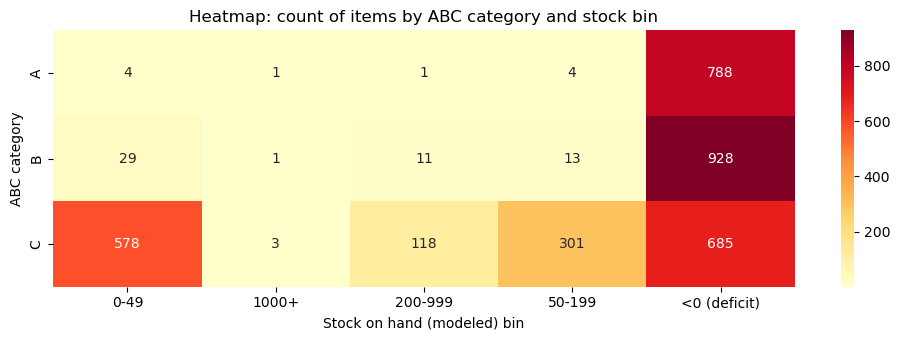

In [20]:
png_local = "/tmp/heatmap_stock_by_abc.png"
plt.figure(figsize=(10, 3.5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Heatmap: count of items by ABC category and stock bin")
plt.xlabel("Stock on hand (modeled) bin")
plt.ylabel("ABC category")
plt.tight_layout()
plt.savefig(png_local, dpi=300)
print("Saved local png:", png_local)

In [21]:
spark.stop()
print("SparkSession stopped")

SparkSession stopped
